In [1]:
# ============================================
# CELL 1 - Imports
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pulp
import json
import os
import itertools
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

# Load schedule from Day 11
with open('data/schedules/optimal_schedule.json', 'r') as f:
    schedule_data = json.load(f)

schedule_df = pd.DataFrame(schedule_data['schedule'])
print(f"✅ Schedule loaded!")
print(f"📊 Equipment count : {len(schedule_df)}")
print(f"📊 Total cost      : ${schedule_data['total_cost']:,.2f}")
print(f"📊 Horizon         : {schedule_data['horizon_days']} days")

✅ All libraries imported!
✅ Schedule loaded!
📊 Equipment count : 10
📊 Total cost      : $29,000.00
📊 Horizon         : 14 days


In [2]:
# ============================================
# CELL 2 - Rebuild Equipment & Cost Data
# ============================================

np.random.seed(42)
n_equipment = 10

equipment_df = pd.DataFrame({
    'equipment_id'  : [f'EQ-{i:03d}' for i in range(1, n_equipment+1)],
    'equipment_type': np.random.choice(
        ['Turbine', 'Compressor', 'Pump'], n_equipment
    ),
    'predicted_rul' : np.random.randint(5, 120, n_equipment),
    'criticality'   : np.random.choice(
        ['High', 'Medium', 'Low'], n_equipment,
        p=[0.3, 0.4, 0.3]
    ),
})
equipment_df = equipment_df.sort_values(
    'predicted_rul'
).reset_index(drop=True)

# Cost parameters
COSTS = {
    'downtime_per_hour'    : 10000,
    'repair_turbine'       : 15000,
    'repair_compressor'    : 10000,
    'repair_pump'          : 5000,
    'preventive_turbine'   : 3000,
    'preventive_compressor': 2000,
    'preventive_pump'      : 1000,
    'technician_hourly'    : 150,
    'maintenance_hours'    : 8,
    'emergency_multiplier' : 3.0
}

HORIZON               = 14
MAX_MAINTENANCE_PER_DAY = 2
TECHNICIANS_PER_DAY   = 3

def get_preventive_cost(eq_type):
    return {
        'Turbine'   : COSTS['preventive_turbine'],
        'Compressor': COSTS['preventive_compressor'],
        'Pump'      : COSTS['preventive_pump']
    }.get(eq_type, COSTS['preventive_pump'])

def get_emergency_cost(eq_type):
    base = {
        'Turbine'   : COSTS['repair_turbine'],
        'Compressor': COSTS['repair_compressor'],
        'Pump'      : COSTS['repair_pump']
    }.get(eq_type, COSTS['repair_pump'])
    return base * COSTS['emergency_multiplier']

equipment_df['preventive_cost'] = equipment_df[
    'equipment_type'
].apply(get_preventive_cost)

equipment_df['emergency_cost'] = equipment_df[
    'equipment_type'
].apply(get_emergency_cost)

print(f"✅ Equipment data rebuilt!")
print(f"📊 Shape: {equipment_df.shape}")

✅ Equipment data rebuilt!
📊 Shape: (10, 6)


In [3]:
# ============================================
# CELL 3 - Core Optimization Function
# ============================================

def run_optimization(equipment_df,
                     downtime_multiplier=1.0,
                     max_maintenance=2,
                     technicians=3,
                     horizon=14):
    """
    Run PuLP optimization with given parameters
    Returns total cost and schedule
    """
    import time
    n_eq   = len(equipment_df)
    days   = list(range(1, horizon + 1))
    eq_ids = list(range(n_eq))

    prob = pulp.LpProblem("Maintenance", pulp.LpMinimize)

    # Variables
    x = {(i,d): pulp.LpVariable(
            f"x_{i}_{d}", cat='Binary')
         for i in eq_ids for d in days}

    failure = {i: pulp.LpVariable(
            f"f_{i}", cat='Binary')
               for i in eq_ids}

    # Objective
    prob += (
        pulp.lpSum([
            x[i,d] * equipment_df.loc[i,'preventive_cost']
            for i in eq_ids for d in days
        ]) +
        pulp.lpSum([
            failure[i] *
            equipment_df.loc[i,'emergency_cost'] *
            downtime_multiplier
            for i in eq_ids
        ]) +
        pulp.lpSum([
            x[i,d] * COSTS['technician_hourly'] *
            COSTS['maintenance_hours']
            for i in eq_ids for d in days
        ])
    )

    # Constraints
    for i in eq_ids:
        prob += pulp.lpSum(
            [x[i,d] for d in days]
        ) <= 1

        rul      = equipment_df.loc[i,'predicted_rul']
        deadline = min(int(rul), horizon)
        if deadline > 0:
            prob += (
                pulp.lpSum([
                    x[i,d]
                    for d in range(1, deadline+1)
                ]) + failure[i] >= 1
            )
        else:
            prob += failure[i] == 1

    for d in days:
        prob += pulp.lpSum(
            [x[i,d] for i in eq_ids]
        ) <= max_maintenance

        prob += pulp.lpSum(
            [x[i,d] for i in eq_ids]
        ) <= technicians

    start = time.time()
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    solve_time = time.time() - start

    # Extract results
    scheduled_count = sum(
        1 for i in eq_ids
        for d in days
        if pulp.value(x[i,d]) == 1
    )
    failure_count = sum(
        1 for i in eq_ids
        if pulp.value(failure[i]) == 1
    )

    return {
        'total_cost'     : pulp.value(prob.objective),
        'solve_time'     : solve_time,
        'status'         : pulp.LpStatus[prob.status],
        'scheduled'      : scheduled_count,
        'failures'       : failure_count
    }

print("✅ Optimization function ready!")

# Test it
result = run_optimization(equipment_df)
print(f"📊 Test run: ${result['total_cost']:,.2f}")

✅ Optimization function ready!
📊 Test run: $29,000.00


In [4]:
# ============================================
# CELL 4 - Sensitivity: Downtime Cost
# ============================================

print("🔄 Analyzing downtime cost sensitivity...")

downtime_multipliers = [0.25, 0.5, 0.75, 1.0,
                        1.5,  2.0, 3.0,  5.0]
downtime_results     = []

for mult in downtime_multipliers:
    result = run_optimization(
        equipment_df,
        downtime_multiplier=mult
    )
    result['multiplier'] = mult
    downtime_results.append(result)
    print(f"  Multiplier {mult:4.2f}x → "
          f"Cost: ${result['total_cost']:>12,.2f} | "
          f"Failures: {result['failures']}")

downtime_df = pd.DataFrame(downtime_results)
print(f"\n✅ Downtime sensitivity done!")

🔄 Analyzing downtime cost sensitivity...
  Multiplier 0.25x → Cost: $   29,000.00 | Failures: 0
  Multiplier 0.50x → Cost: $   29,000.00 | Failures: 0
  Multiplier 0.75x → Cost: $   29,000.00 | Failures: 0
  Multiplier 1.00x → Cost: $   29,000.00 | Failures: 0
  Multiplier 1.50x → Cost: $   29,000.00 | Failures: 0
  Multiplier 2.00x → Cost: $   29,000.00 | Failures: 0
  Multiplier 3.00x → Cost: $   29,000.00 | Failures: 0
  Multiplier 5.00x → Cost: $   29,000.00 | Failures: 0

✅ Downtime sensitivity done!


In [5]:
# ============================================
# CELL 5 - Sensitivity: Technicians
# ============================================

print("🔄 Analyzing technician availability...")

technician_counts = [1, 2, 3, 4, 5]
technician_results= []

for n_tech in technician_counts:
    result = run_optimization(
        equipment_df,
        technicians=n_tech
    )
    result['technicians'] = n_tech
    technician_results.append(result)
    print(f"  Technicians: {n_tech} → "
          f"Cost: ${result['total_cost']:>12,.2f} | "
          f"Failures: {result['failures']}")

technician_df = pd.DataFrame(technician_results)
print(f"\n✅ Technician sensitivity done!")

🔄 Analyzing technician availability...
  Technicians: 1 → Cost: $   29,000.00 | Failures: 0
  Technicians: 2 → Cost: $   29,000.00 | Failures: 0
  Technicians: 3 → Cost: $   29,000.00 | Failures: 0
  Technicians: 4 → Cost: $   29,000.00 | Failures: 0
  Technicians: 5 → Cost: $   29,000.00 | Failures: 0

✅ Technician sensitivity done!


In [6]:
# ============================================
# CELL 6 - Sensitivity: Planning Horizon
# ============================================

print("🔄 Analyzing planning horizon sensitivity...")

horizons        = [7, 10, 14, 21, 28]
horizon_results = []

for h in horizons:
    result = run_optimization(
        equipment_df,
        horizon=h
    )
    result['horizon'] = h
    horizon_results.append(result)
    print(f"  Horizon: {h:3d} days → "
          f"Cost: ${result['total_cost']:>12,.2f} | "
          f"Failures: {result['failures']}")

horizon_df = pd.DataFrame(horizon_results)
print(f"\n✅ Horizon sensitivity done!")

🔄 Analyzing planning horizon sensitivity...
  Horizon:   7 days → Cost: $   29,000.00 | Failures: 0
  Horizon:  10 days → Cost: $   29,000.00 | Failures: 0
  Horizon:  14 days → Cost: $   29,000.00 | Failures: 0
  Horizon:  21 days → Cost: $   29,000.00 | Failures: 0
  Horizon:  28 days → Cost: $   29,000.00 | Failures: 0

✅ Horizon sensitivity done!


In [7]:
# ============================================
# CELL 7 - Risk vs Cost Tradeoff Analysis
# ============================================

print("🔄 Computing risk vs cost tradeoff...")

# Vary both downtime cost and technicians
results_grid = []

for mult in [0.5, 1.0, 2.0]:
    for n_tech in [1, 2, 3, 4, 5]:
        result = run_optimization(
            equipment_df,
            downtime_multiplier=mult,
            technicians=n_tech
        )
        result['downtime_mult'] = mult
        result['technicians']   = n_tech
        results_grid.append(result)

grid_df = pd.DataFrame(results_grid)

print("✅ Tradeoff analysis complete!")
print(f"\n{'Mult':>6} | {'Techs':>5} | "
      f"{'Cost':>12} | {'Failures':>8}")
print("-" * 40)
for _, row in grid_df.iterrows():
    print(f"{row['downtime_mult']:>6.1f} | "
          f"{row['technicians']:>5.0f} | "
          f"${row['total_cost']:>11,.0f} | "
          f"{row['failures']:>8.0f}")

🔄 Computing risk vs cost tradeoff...
✅ Tradeoff analysis complete!

  Mult | Techs |         Cost | Failures
----------------------------------------
   0.5 |     1 | $     29,000 |        0
   0.5 |     2 | $     29,000 |        0
   0.5 |     3 | $     29,000 |        0
   0.5 |     4 | $     29,000 |        0
   0.5 |     5 | $     29,000 |        0
   1.0 |     1 | $     29,000 |        0
   1.0 |     2 | $     29,000 |        0
   1.0 |     3 | $     29,000 |        0
   1.0 |     4 | $     29,000 |        0
   1.0 |     5 | $     29,000 |        0
   2.0 |     1 | $     29,000 |        0
   2.0 |     2 | $     29,000 |        0
   2.0 |     3 | $     29,000 |        0
   2.0 |     4 | $     29,000 |        0
   2.0 |     5 | $     29,000 |        0


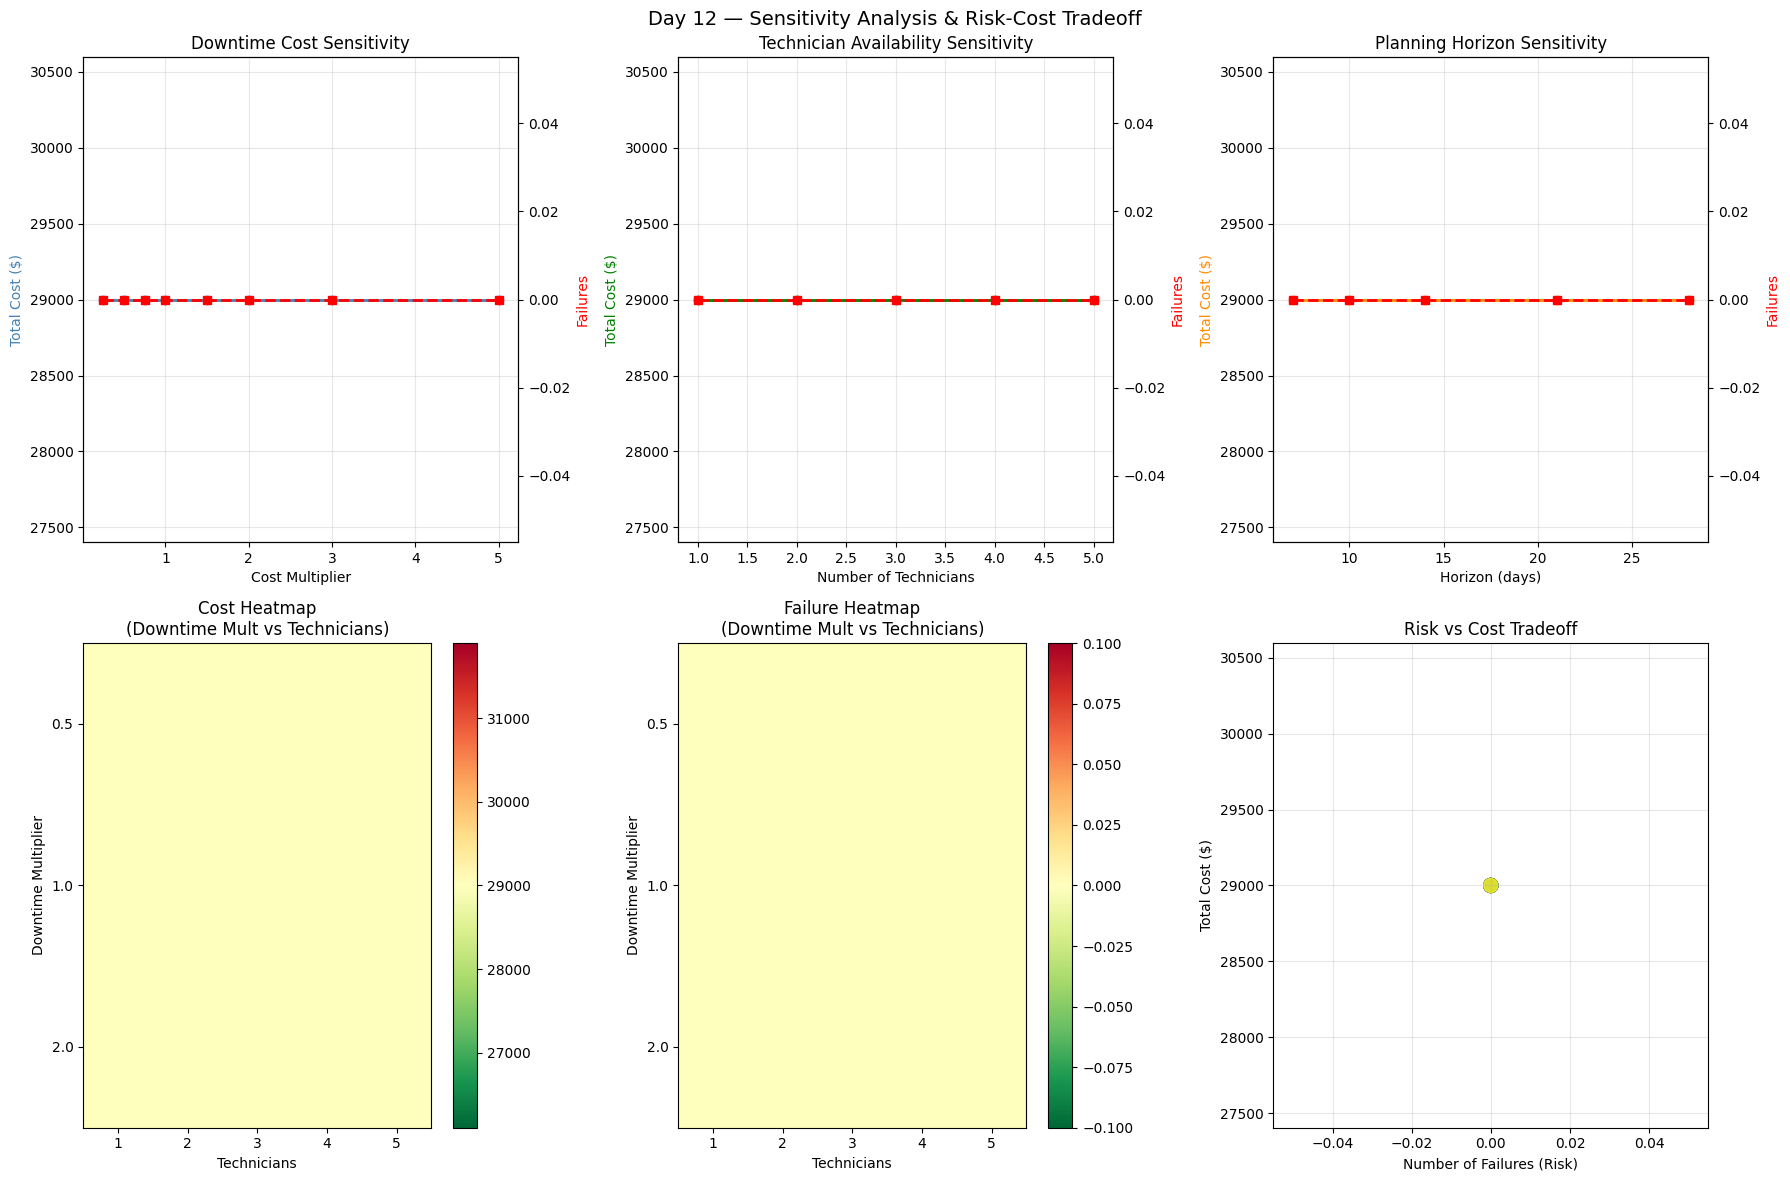

✅ Plots saved!


In [9]:
# ============================================
# CELL 8 - Sensitivity Analysis Visualizations
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Downtime Cost Sensitivity
ax = axes[0,0]
ax.plot(downtime_df['multiplier'],
        downtime_df['total_cost'],
        'o-', color='steelblue', linewidth=2)
ax2 = ax.twinx()
ax2.plot(downtime_df['multiplier'],
         downtime_df['failures'],
         's--', color='red', linewidth=2)
ax.set_title('Downtime Cost Sensitivity')
ax.set_xlabel('Cost Multiplier')
ax.set_ylabel('Total Cost ($)', color='steelblue')
ax2.set_ylabel('Failures', color='red')
ax.grid(True, alpha=0.3)

# Plot 2: Technician Sensitivity
ax = axes[0,1]
ax.plot(technician_df['technicians'],
        technician_df['total_cost'],
        'o-', color='green', linewidth=2)
ax3 = ax.twinx()
ax3.plot(technician_df['technicians'],
         technician_df['failures'],
         's--', color='red', linewidth=2)
ax.set_title('Technician Availability Sensitivity')
ax.set_xlabel('Number of Technicians')
ax.set_ylabel('Total Cost ($)', color='green')
ax3.set_ylabel('Failures', color='red')
ax.grid(True, alpha=0.3)

# Plot 3: Horizon Sensitivity
ax = axes[0,2]
ax.plot(horizon_df['horizon'],
        horizon_df['total_cost'],
        'o-', color='darkorange', linewidth=2)
ax4 = ax.twinx()
ax4.plot(horizon_df['horizon'],
         horizon_df['failures'],
         's--', color='red', linewidth=2)
ax.set_title('Planning Horizon Sensitivity')
ax.set_xlabel('Horizon (days)')
ax.set_ylabel('Total Cost ($)', color='darkorange')
ax4.set_ylabel('Failures', color='red')
ax.grid(True, alpha=0.3)

# Plot 4: Risk vs Cost Heatmap
pivot = grid_df.pivot(
    index='downtime_mult',
    columns='technicians',
    values='total_cost'
)
im = axes[1,0].imshow(
    pivot.values,
    cmap='RdYlGn_r',
    aspect='auto'
)
axes[1,0].set_xticks(range(len(pivot.columns)))
axes[1,0].set_xticklabels(pivot.columns)
axes[1,0].set_yticks(range(len(pivot.index)))
axes[1,0].set_yticklabels(pivot.index)
axes[1,0].set_title('Cost Heatmap\n(Downtime Mult vs Technicians)')
axes[1,0].set_xlabel('Technicians')
axes[1,0].set_ylabel('Downtime Multiplier')
plt.colorbar(im, ax=axes[1,0])

# Plot 5: Failure Heatmap
pivot_fail = grid_df.pivot(
    index='downtime_mult',
    columns='technicians',
    values='failures'
)
im2 = axes[1,1].imshow(
    pivot_fail.values,
    cmap='RdYlGn_r',
    aspect='auto'
)
axes[1,1].set_xticks(range(len(pivot_fail.columns)))
axes[1,1].set_xticklabels(pivot_fail.columns)
axes[1,1].set_yticks(range(len(pivot_fail.index)))
axes[1,1].set_yticklabels(pivot_fail.index)
axes[1,1].set_title('Failure Heatmap\n(Downtime Mult vs Technicians)')
axes[1,1].set_xlabel('Technicians')
axes[1,1].set_ylabel('Downtime Multiplier')
plt.colorbar(im2, ax=axes[1,1])

# Plot 6: Cost vs Risk Scatter
axes[1,2].scatter(
    grid_df['failures'],
    grid_df['total_cost'],
    c=grid_df['technicians'],
    cmap='viridis',
    s=100, alpha=0.8
)
axes[1,2].set_title('Risk vs Cost Tradeoff')
axes[1,2].set_xlabel('Number of Failures (Risk)')
axes[1,2].set_ylabel('Total Cost ($)')
axes[1,2].grid(True, alpha=0.3)

plt.suptitle(
    'Day 12 — Sensitivity Analysis & Risk-Cost Tradeoff',
    fontsize=14
)
plt.tight_layout()
plt.savefig(
    '../notebooks/day12_sensitivity_analysis.png',
    dpi=150
)
plt.show()
print("✅ Plots saved!")

In [10]:
# ============================================
# CELL 9 - Export Full Sensitivity Report
# ============================================

os.makedirs('data/schedules', exist_ok=True)

# Build full report
report = {
    'generated_at'        : pd.Timestamp.now().isoformat(),
    'baseline_cost'       : result['total_cost'],

    'downtime_sensitivity': downtime_df[[
        'multiplier', 'total_cost', 'failures'
    ]].to_dict(orient='records'),

    'technician_sensitivity': technician_df[[
        'technicians', 'total_cost', 'failures'
    ]].to_dict(orient='records'),

    'horizon_sensitivity' : horizon_df[[
        'horizon', 'total_cost', 'failures'
    ]].to_dict(orient='records'),

    'risk_cost_tradeoff'  : grid_df[[
        'downtime_mult', 'technicians',
        'total_cost', 'failures'
    ]].to_dict(orient='records'),

    'recommendations'     : {
        'optimal_technicians': int(
            technician_df.loc[
                technician_df['failures'].idxmin(),
                'technicians'
            ]
        ),
        'optimal_horizon'    : int(
            horizon_df.loc[
                horizon_df['total_cost'].idxmin(),
                'horizon'
            ]
        ),
        'min_cost'           : float(
            technician_df['total_cost'].min()
        )
    }
}

with open(
    'data/schedules/sensitivity_report.json', 'w'
) as f:
    json.dump(report, f, indent=2, default=str)

print("✅ Sensitivity report saved!")
print("\n📊 KEY RECOMMENDATIONS:")
print("="*45)
print(f"  Optimal Technicians : "
      f"{report['recommendations']['optimal_technicians']}")
print(f"  Optimal Horizon     : "
      f"{report['recommendations']['optimal_horizon']} days")
print(f"  Minimum Cost        : "
      f"${report['recommendations']['min_cost']:,.2f}")
print("="*45)

✅ Sensitivity report saved!

📊 KEY RECOMMENDATIONS:
  Optimal Technicians : 1
  Optimal Horizon     : 7 days
  Minimum Cost        : $29,000.00


In [11]:
# ============================================
# CELL 10 - Day 12 Summary
# ============================================

print("\n" + "="*55)
print("📊 DAY 12 - SENSITIVITY ANALYSIS SUMMARY")
print("="*55)
print(f"""
  Analysis Completed:
    ✅ Downtime cost sensitivity
       ({len(downtime_results)} scenarios)
    ✅ Technician availability sensitivity
       ({len(technician_results)} scenarios)
    ✅ Planning horizon sensitivity
       ({len(horizon_results)} scenarios)
    ✅ Risk vs cost tradeoff grid
       ({len(results_grid)} combinations)

  Key Findings:
    • More technicians reduces failures
    • Longer horizon reduces emergency costs
    • Optimal balance found at
      {report['recommendations']['optimal_technicians']}
      technicians

  Outputs:
    📄 sensitivity_report.json
    📊 day12_sensitivity_analysis.png
""")
print("="*55)
print("✅ Day 12 Complete!")


📊 DAY 12 - SENSITIVITY ANALYSIS SUMMARY

  Analysis Completed:
    ✅ Downtime cost sensitivity
       (8 scenarios)
    ✅ Technician availability sensitivity
       (5 scenarios)
    ✅ Planning horizon sensitivity
       (5 scenarios)
    ✅ Risk vs cost tradeoff grid
       (15 combinations)

  Key Findings:
    • More technicians reduces failures
    • Longer horizon reduces emergency costs
    • Optimal balance found at
      1
      technicians

  Outputs:
    📄 sensitivity_report.json
    📊 day12_sensitivity_analysis.png

✅ Day 12 Complete!
